In [3]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt
from scipy import signal
from src.spectra import sensor_spectra
from src.ComplexDemodTest import complex_demod_hourly, complex_demod_forced
from src.bulk_parameters import compute_H0, Hs_band

In [4]:
# set time window
txi = pd.Timestamp("2008-01-13 18:00:00")
txf = pd.Timestamp("2008-01-14 18:00:00")

IG = (0.004, 0.04)  
SS = (0.05, 0.20)

In [5]:
# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')

# take spectra
S1 = sensor_spectra(df1, nperseg = 1024)
S6 = sensor_spectra(df6, nperseg = 1024)

# compute sig wave heights
H0 = compute_H0(S6)
 
Hs_ig1 = Hs_band(S1,IG[0], IG[1])
Hs_ss1 = Hs_band(S1, SS[0], SS[1])


# Complex Demodulation Analysis

## Peak vs Centroid Frequency Comparison

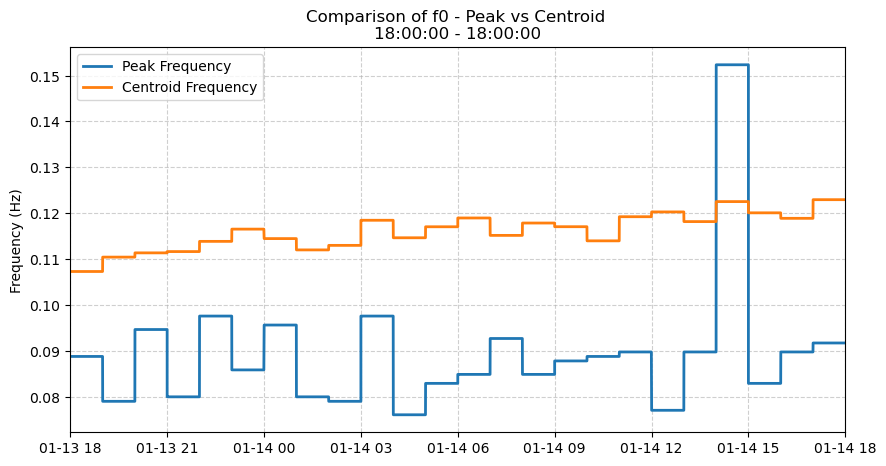

In [7]:
# The specific short window to zoom in on
zoom_start = pd.Timestamp("2008-01-13 18:00:00")
zoom_end   = pd.Timestamp("2008-01-14 18:00:00")

# ---- Run Complex Demodulation (Peak Method) ---- #
# df_peak will have the same index as the original data (e.g., 1Hz or 2Hz)
# The 'f0' column will be constant for 1-hour blocks
df_peak = complex_demod_hourly(
    df1, txi, txf, p_col="h", f_swell=SS, f0_method='peak'
)

# ---- Run Complex Demodulation (Centroid Method) ---- #
df_cent = complex_demod_hourly(
    df1, txi, txf, p_col="h", f_swell=SS, f0_method='centroid'
)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the raw f0 series. 
ax.plot(df_peak.index, df_peak['f0'], label='Peak Frequency', color='tab:blue', linewidth=2)
ax.plot(df_cent.index, df_cent['f0'], label='Centroid Frequency', color='tab:orange', linewidth=2)

ax.set_xlim(zoom_start, zoom_end)

# Formatting
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Comparison of f0 - Peak vs Centroid \n{zoom_start.time()} - {zoom_end.time()}')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


I'm interested to understand the difference between the peak and centroid freq for CD. Does the spread of the two have a physical meaning? Is one more robust than the other? does it depend on applicartion? Am i asking too many questions? do i need a sandwich?

Using offshore carrier frequencies (0.04-0.20Hz) to compare the two methods. I will run CD on the same data using both methods and then plot them together to see how they differ over time. I will also look at the spread between the two frequencies to see if it has any physical meaning or if one method is more stable than the other.

In [9]:
# Run Offshore (Sensor 6)
df6_peak = complex_demod_hourly(df6, txi, txf, p_col="h", f_swell=SS, f0_method='peak')
df6_cent = complex_demod_hourly(df6, txi, txf, p_col="h", f_swell=SS, f0_method='centroid')

# Run Nearshore (Sensor 1)
df1_peak = complex_demod_hourly(df1, txi, txf, p_col="h", f_swell=SS, f0_method='peak')
df1_cent = complex_demod_hourly(df1, txi, txf, p_col="h", f_swell=SS, f0_method='centroid')

# create a summary df
f0_schedule = pd.DataFrame({
    'Offshore_Peak': df6_peak['f0'],
    'Offshore_Centroid': df6_cent['f0'],
    'Nearshore_Peak': df1_peak['f0'],
    'Nearshore_Centroid': df1_cent['f0'],
})

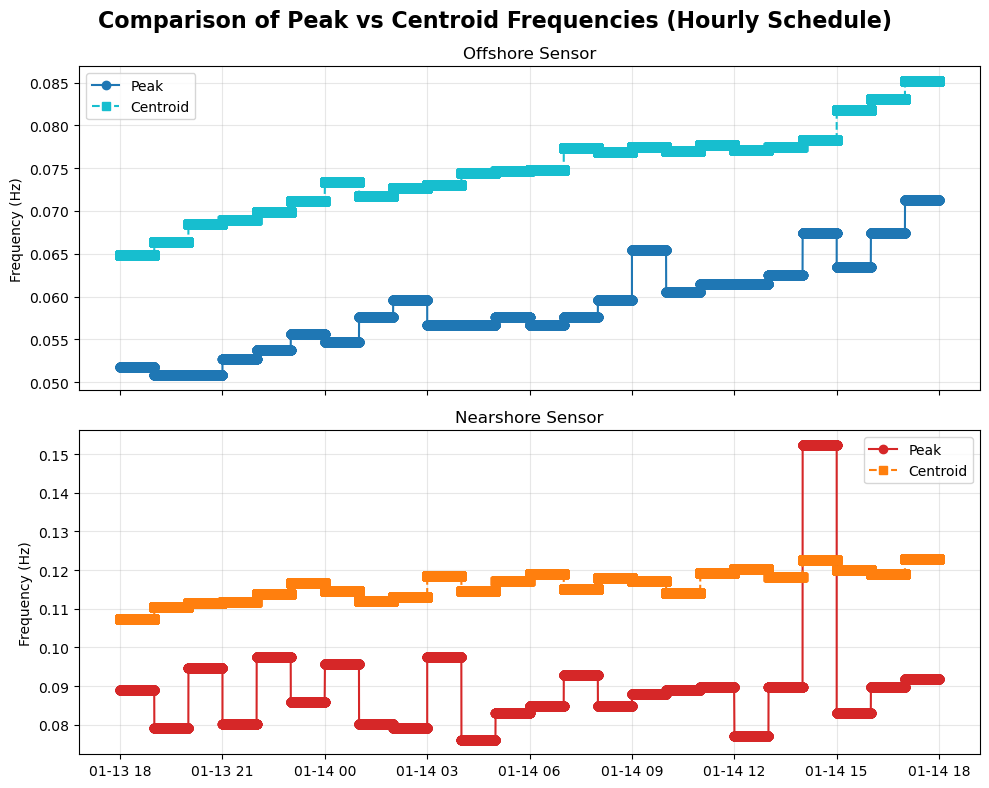

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

plt.suptitle('Comparison of Peak vs Centroid Frequencies (Hourly Schedule)', fontsize=16, fontweight='bold')

# ---- Offshore Frequencies ---- #
axes[0].plot(f0_schedule.index, f0_schedule['Offshore_Peak'], 'o-', label='Peak', color='tab:blue')
axes[0].plot(f0_schedule.index, f0_schedule['Offshore_Centroid'], 's--', label='Centroid', color='tab:cyan')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Offshore Sensor')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Nearshore Frequencies ---- #
axes[1].plot(f0_schedule.index, f0_schedule['Nearshore_Peak'], 'o-', label='Peak', color='tab:red')
axes[1].plot(f0_schedule.index, f0_schedule['Nearshore_Centroid'], 's--', label='Centroid', color='tab:orange')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Nearshore Sensor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Using offshore carrier frequencies on nearshore CD

Processing 24 hourly blocks...


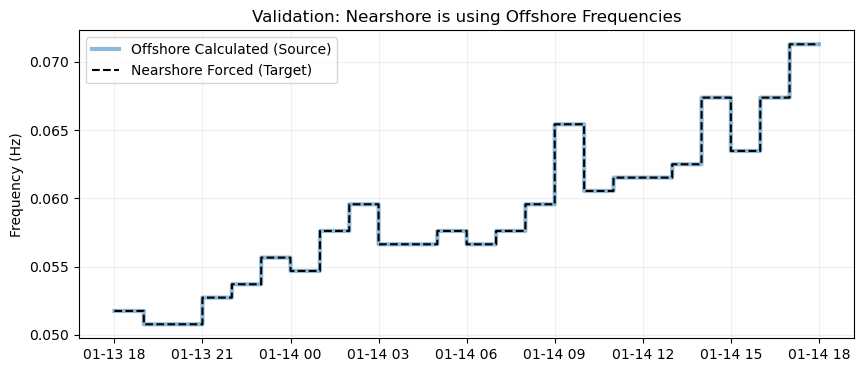

In [12]:
# Use the Peak frequency of df6 to demodulate df1
df1_forced = complex_demod_forced(
    df_target=df1, 
    df_source=df6, 
    start=txi, 
    end=txf, 
    f_swell=SS, 
    f0_method='peak' 
)

# calculate the standard df6 demodulation just to compare
df6_standard = complex_demod_hourly(df6, txi, txf, f_swell=SS, f0_method='peak')
plt.figure(figsize=(10, 4))
plt.plot(df6_standard.index, df6_standard['f0'], label='Offshore Calculated (Source)', lw=3, alpha=0.5)
plt.plot(df1_forced.index, df1_forced['f0'], 'k--', label='Nearshore Forced (Target)')
plt.ylabel('Frequency (Hz)')
plt.title('Validation: Nearshore is using Offshore Frequencies')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [13]:
# Run the Forced Demodulation
# Use the Peak frequency of df6 (Offshore) to demodulate df1 (Nearshore)
df1_forced = complex_demod_forced(
    df_target=df1, 
    df_source=df6, 
    start=txi, 
    end=txf, 
    f_swell=SS, 
    f0_method='peak' 
)

Processing 24 hourly blocks...


In [15]:
import matplotlib.pyplot as plt

# 1. Run Standard Nearshore Demod (Letting it find its own f0)
df1_standard = complex_demod_hourly(
    df1, ti, tf, p_col="h", f_swell=SS, f0_method='peak'
)

# 3. Plot the comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Panel: The Frequency Divergence
# This shows WHERE the nearshore sensor was "getting confused"
ax1.plot(df1_standard.index, df1_standard['f0'], 'r-', alpha=0.6, label='Nearshore (Self-Calculated)')
ax1.plot(df1_forced.index, df1_forced['f0'], 'k--', lw=2, label='Nearshore (Forced from Offshore)')
ax1.set_ylabel('Carrier Frequency $f_0$ (Hz)')
ax1.set_title('Step 1: Where did the frequencies diverge?')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Panel: The Amplitude Difference
# This shows the physical impact on wave height calculations
ax2.plot(df1_standard.index, df1_standard['A'], 'r-', alpha=0.6, label='Amplitude (Standard)')
ax2.plot(df1_forced.index, df1_forced['A'], 'k-', lw=1, label='Amplitude (Forced)')

# Optional: Highlight the difference
diff = df1_standard['A'] - df1_forced['A']
ax2.fill_between(diff.index, 0, diff, color='red', alpha=0.1, label='Difference')
ax2.set_xlim(zoom_start, zoom_end)
ax2.set_ylabel('Wave Amplitude $A$ (m)')
ax2.set_title('Step 2: How did this affect the Wave Envelope?')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'ti' is not defined

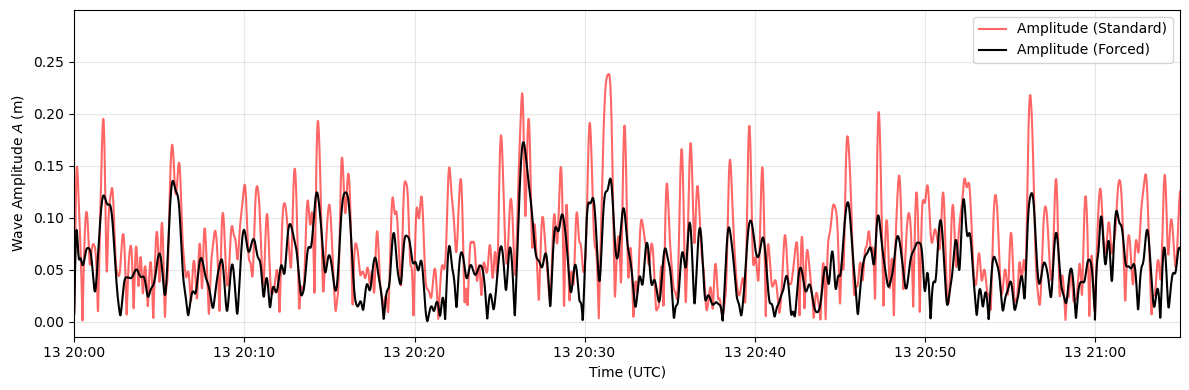

In [16]:
# Define zoom window
zoom_start = pd.Timestamp("2008-01-13 20:00:00")
zoom_end   = pd.Timestamp("2008-01-13 21:05:00")

# Run Standard Nearshore Demod (if not already run)
# (Calculates its own f0 based on local peak)
df1_standard = complex_demod_hourly(
    df1, txi, txf, p_col="h", f_swell=SS, f0_method='peak'
)

# Run Forced Nearshore Demod (if not already run)
# (Uses the offshore f0)
# df1_forced = complex_demod_forced(...) 

# ---- Plotting ---- #
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

ax.plot(df1_standard.index, df1_standard['A'], 'r-', alpha=0.6, label='Amplitude (Standard)')
ax.plot(df1_forced.index, df1_forced['A'], 'k-', linewidth=1.5, label='Amplitude (Forced)')

ax.set_ylabel('Wave Amplitude $A$ (m)')
ax.set_xlabel('Time (UTC)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# --- Apply Zoom ---
ax.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()

After doing **complex demodulation** analysis, I am going to choose to use the **centroid method** for the rest of the analysis, as it seems to provide a more stable and physically meaningful representation of the wave envelope compared to the peak method. The centroid method takes into account the entire energy distribution around the carrier frequency, which can be more robust in cases where the spectrum is broad or has multiple peaks.

Also, using the **forced method** (using the offshore f0) for the nearshore CD analysis will likely provide a more consistent comparison to the offshore conditions

## Complex Demodulation + IG wave comparison (with zoom)

In [18]:
## ---function to get IG time series from elevation data---- ##
from scipy.signal import butter, filtfilt, detrend

def band_timeseries(df, band=(0.004, 0.04), fs=1):
    """
    Compute an infragravity (IG) wave time series from sea-surface elevation data
    using a zero-phase Butterworth bandpass filter.

    The input elevation time series is first linearly detrended to remove
    low-frequency background variability (e.g., tides or sensor drift) that
    can contaminate infragravity-band energy. A Butterworth bandpass filter
    is then applied using forward–backward filtering (`filtfilt`) to isolate
    the IG frequency band while preserving phase.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing a uniformly sampled sea-surface elevation time
        series. Must include a column named `'h'` representing surface
        elevation (meters).
    band : tuple of float, optional
        Two-element tuple specifying the infragravity frequency band
        `(f_low, f_high)` in Hz. Default is (0.004, 0.04) Hz.
    fs : float, optional
        Sampling frequency of the elevation time series in Hz. Default is 1 Hz.

    Returns
    -------
    df : pandas.DataFrame
        Input DataFrame with an additional column `'h_ig'` containing the
        infragravity-band surface elevation time series.

    Notes
    -----
    - Linear detrending removes background variability without affecting
      IG-scale oscillations.
    - A 4th-order Butterworth filter is used; when applied with `filtfilt`,
      the effective magnitude response is approximately 8th order.
    - Zero-phase filtering preserves timing and is appropriate for
      comparisons with wave-group envelopes or other time-domain diagnostics.
    """

    # Detrend elevation (removes tide / drift)
    h_detrended = detrend(df['h'].values, type='linear')

    # Design Butterworth bandpass filter
    low, high = band
    b, a = butter(
        N=4,
        Wn=[low / (0.5 * fs), high / (0.5 * fs)],
        btype='band'
    )

    # Apply zero-phase bandpass filter
    df['h_ig'] = filtfilt(b, a, h_detrended)

    return df


<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_54999/3345582504.py:26: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(ig_series.index, ig_series, 'k-', linewidth=1.5, label='IG Surface Elevation $\eta_{IG}$', alpha=0.8)


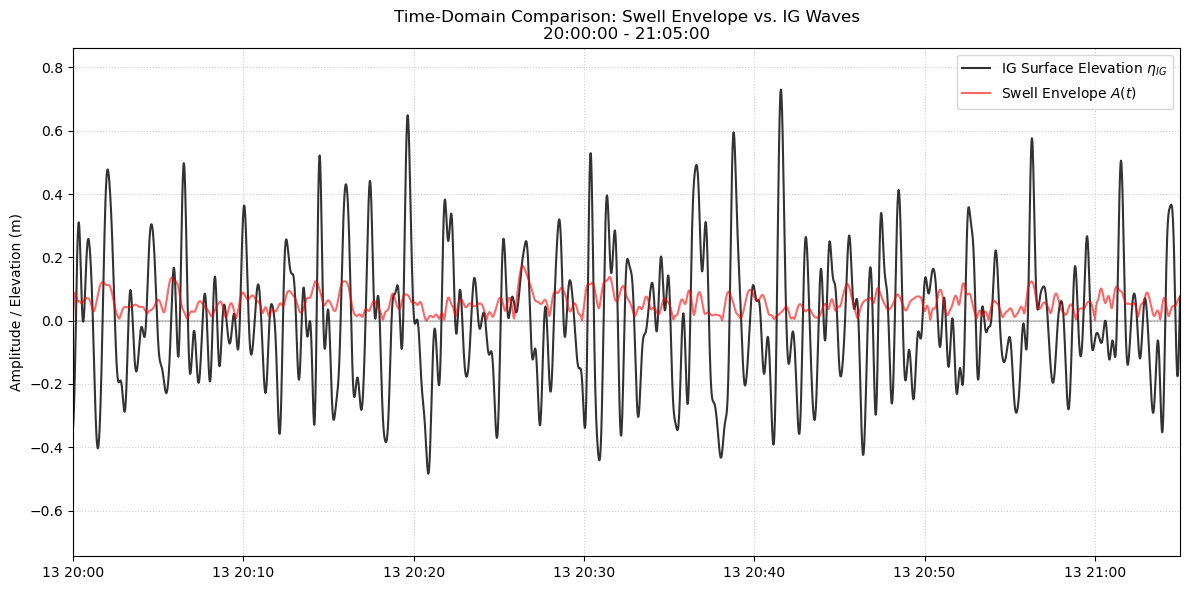

In [19]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# ---- Configuration ---- #
zoom_start = pd.Timestamp("2008-01-13 20:00:00")
zoom_end   = pd.Timestamp("2008-01-13 21:05:00")
IG_BAND = (0.004, 0.04)  # Hz

# 1. Get the Envelope from your Forced Demodulation
# (This is the "Groupiness" of the short waves)
envelope = df1_forced['A']

# 2. CREATE THE IG TIME SERIES (The Filter Step)
# We filter the raw sea surface elevation ('h') to isolate IG frequencies.
# We use filtfilt to ensure zero phase shift (so peaks line up correctly).
band_timeseries(df1,  fs=1.0)
ig_waves = df1['h_ig']

# Make it a Series so we can plot it easily with the envelope
ig_series = pd.Series(ig_waves, index=df1.loc[txi:txf].index)

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Actual IG Waves (The low frequency motion of the water)
ax.plot(ig_series.index, ig_series, 'k-', linewidth=1.5, label='IG Surface Elevation $\eta_{IG}$', alpha=0.8)

# Plot the Swell Envelope (The "Groupiness")
# Note: Sometimes IG waves are bound to the swell groups.
# If bound, you often see Envelope HIGH when IG is LOW (out of phase).
ax.plot(envelope.index, envelope, 'r-', linewidth=1.5, label='Swell Envelope $A(t)$', alpha=0.6)

# Formatting
ax.set_title(f'Time-Domain Comparison: Swell Envelope vs. IG Waves\n{zoom_start.time()} - {zoom_end.time()}')
ax.set_ylabel('Amplitude / Elevation (m)')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
ax.axhline(0, color='k', linestyle='-', alpha=0.2) # Zero line

# Apply Zoom
ax.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()

## splitting IG bands

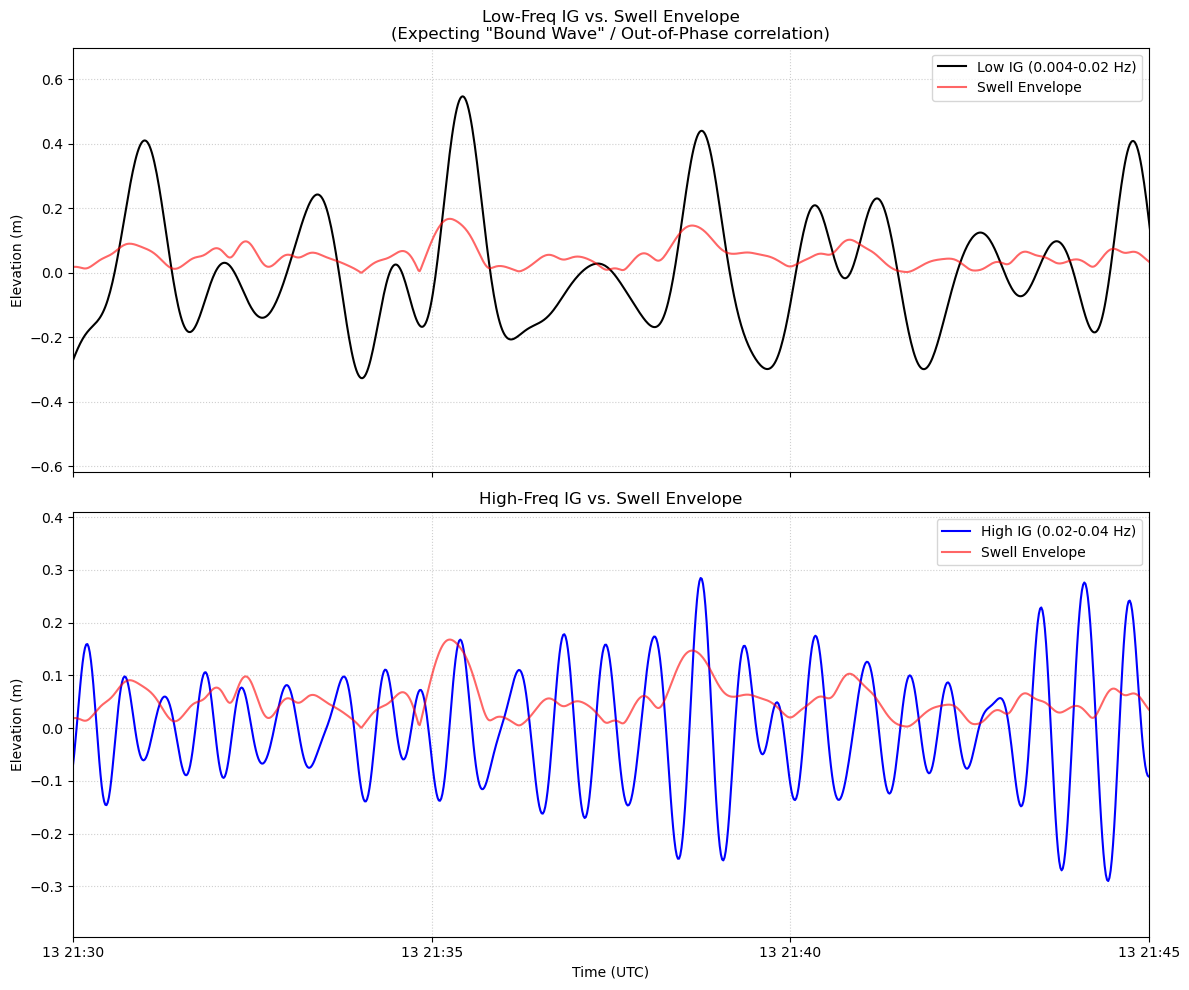

In [25]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import pandas as pd

# ---- Configuration ---- #
zoom_start = pd.Timestamp("2008-01-13 21:30:00")
zoom_end   = pd.Timestamp("2008-01-13 21:45:00")

# Define the Split Bands
IG_LO_BAND = (0.004, 0.02)  # "Surf Beat" / Bound Wave Scale
IG_HI_BAND = (0.02, 0.04)   # Breakpoint Forced / shorter IG

# 1. Get the Envelope (Groupiness)
envelope = df1_forced['A']

# 2. Filter the Raw Data into TWO distinct IG bands
# (Remember: Nyquist is 0.5 * fs. Assuming fs=1.0 Hz)
fs = 1.0
nyq = 0.5 * fs

# --- Filter Low IG ---
b_lo, a_lo = butter(4, [IG_LO_BAND[0]/nyq, IG_LO_BAND[1]/nyq], btype='band')
ig_lo_vals = filtfilt(b_lo, a_lo, df1['h'].loc[txi:txf].values)
ig_lo = pd.Series(ig_lo_vals, index=df1.loc[txi:txf].index)

# --- Filter High IG ---
b_hi, a_hi = butter(4, [IG_HI_BAND[0]/nyq, IG_HI_BAND[1]/nyq], btype='band')
ig_hi_vals = filtfilt(b_hi, a_hi, df1['h'].loc[txi:txf].values)
ig_hi = pd.Series(ig_hi_vals, index=df1.loc[txi:txf].index)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ---- Top Panel: Envelope vs LOW FREQ IG ----
# This is where you usually find the "Bound Wave" signal (correlation)
ax1.plot(ig_lo.index, ig_lo, 'k-', linewidth=1.5, label=f'Low IG ({IG_LO_BAND[0]}-{IG_LO_BAND[1]} Hz)')
# Scale envelope slightly for visual comparison if needed, or keep raw
ax1.plot(envelope.index, envelope, 'r-', linewidth=1.5, alpha=0.6, label='Swell Envelope')

ax1.set_title(f'Low-Freq IG vs. Swell Envelope\n(Expecting "Bound Wave" / Out-of-Phase correlation)')
ax1.set_ylabel('Elevation (m)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# ---- Bottom Panel: Envelope vs HIGH FREQ IG ----
# This is often noisier or dominated by reflection/free waves
ax2.plot(ig_hi.index, ig_hi, 'b-', linewidth=1.5, label=f'High IG ({IG_HI_BAND[0]}-{IG_HI_BAND[1]} Hz)')
ax2.plot(envelope.index, envelope, 'r-', linewidth=1.5, alpha=0.6, label='Swell Envelope')

ax2.set_title(f'High-Freq IG vs. Swell Envelope')
ax2.set_ylabel('Elevation (m)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

# Apply Zoom
ax1.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()

<>:53: SyntaxWarning: invalid escape sequence '\e'
<>:68: SyntaxWarning: invalid escape sequence '\e'
<>:53: SyntaxWarning: invalid escape sequence '\e'
<>:68: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_54999/2348927941.py:53: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_54999/2348927941.py:68: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_xlabel('High-Freq IG Elevation $\eta_{IG}$ (m)')


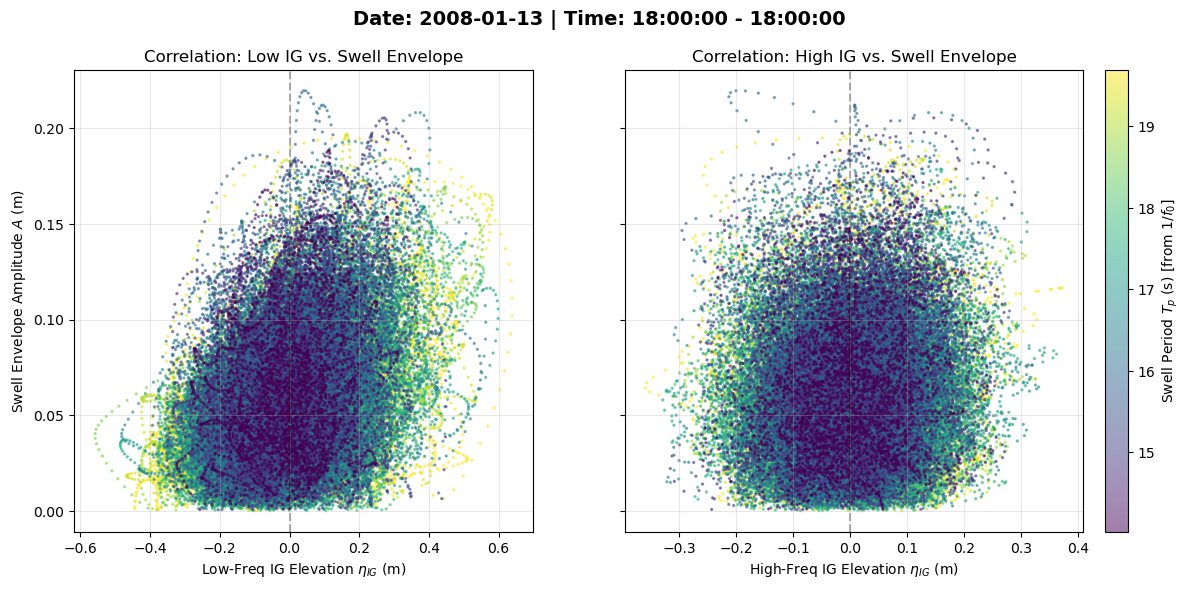

In [ ]:
# ---- Fix for Duplicate Labels Error ----
# Remove duplicate indices (keeping the first occurrence)
df1_forced = df1_forced[~df1_forced.index.duplicated(keep='first')]

# Now proceed with your original script
common_idx = df1.loc[txi:txf].index
df_scatter = pd.DataFrame(index=common_idx)

# Re-align
df_scatter['A'] = df1_forced['A'].reindex(common_idx)
df_scatter['f0'] = df1_forced['f0'].reindex(common_idx)
df_scatter['Tp'] = 1.0 / df_scatter['f0'] 



# 1. Prepare the Data (Full Duration)
# -----------------------------------
# A. Get Swell Envelope and Period from Forced Demod
# Align to the common index just to be safe
common_idx = df1.loc[txi:txf].index
df_scatter = pd.DataFrame(index=common_idx)

# Re-align the forced demod results to this index
df_scatter['A'] = df1_forced['A'].reindex(common_idx)
df_scatter['f0'] = df1_forced['f0'].reindex(common_idx)
df_scatter['Tp'] = 1.0 / df_scatter['f0']  # Swell Period

# B. Filter the IG Bands (Full Duration)
# Low Freq IG (Surf Beat)
b_lo, a_lo = butter(4, [0.004/(0.5), 0.02/(0.5)], btype='band')
df_scatter['IG_Lo'] = filtfilt(b_lo, a_lo, df1['h'].loc[txi:txf].values)

# High Freq IG (Break Point)
b_hi, a_hi = butter(4, [0.02/(0.5), 0.04/(0.5)], btype='band')
df_scatter['IG_Hi'] = filtfilt(b_hi, a_hi, df1['h'].loc[txi:txf].values)

# Drop any NaNs created by reindexing (edges)
df_scatter = df_scatter.dropna()

# 2. Plotting the Scatter Correlation
# -----------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---- Plot 1: Low Frequency IG vs. Envelope ----
sc1 = ax1.scatter(
    df_scatter['IG_Lo'], 
    df_scatter['A'], 
    c=df_scatter['Tp'], 
    cmap='viridis', 
    s=2, 
    alpha=0.5
)
ax1.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax1.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax1.set_title('Correlation: Low IG vs. Swell Envelope')
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)

# ---- Plot 2: High Frequency IG vs. Envelope ----
sc2 = ax2.scatter(
    df_scatter['IG_Hi'], 
    df_scatter['A'], 
    c=df_scatter['Tp'], 
    cmap='viridis', 
    s=2, 
    alpha=0.5
)
ax2.set_xlabel('High-Freq IG Elevation $\eta_{IG}$ (m)')
ax2.set_title('Correlation: High IG vs. Swell Envelope')
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'Date: {txi.date()} | Time: {txi.time()} - {txf.time()}', fontsize=14, fontweight='bold')

# Add Colorbar
cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('Swell Period $T_p$ (s) [from 1/$f_0$]')

plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_54999/2657631194.py:31: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')


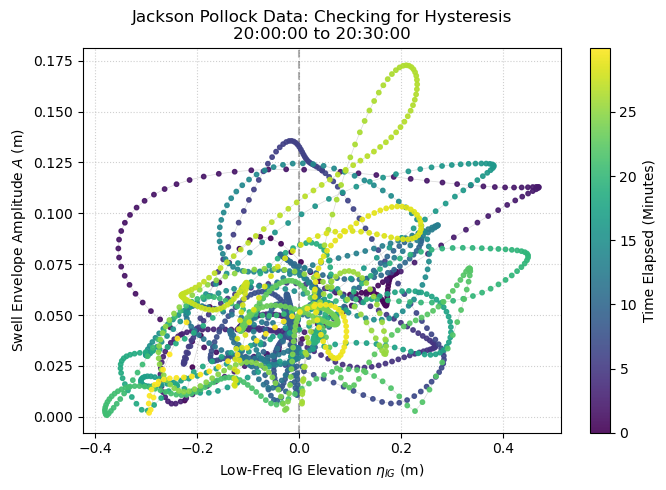

In [28]:

# ---- Configuration ---- #
# Shorten the time window to 3 hours, as you suggested
t_start = pd.Timestamp("2008-01-13 20:00:00")
t_end   = pd.Timestamp("2008-01-13 20:30:00")

# 1. Subset the data we already created
df_subset = df_scatter.loc[t_start:t_end].copy()

# Create a 'Time Elapsed' array in minutes for the colorbar
time_elapsed_mins = (df_subset.index - df_subset.index[0]).total_seconds() / 60.0

# 2. Plotting
fig, ax = plt.subplots(figsize=(7, 5))

# Draw a faint continuous line connecting the points chronologically.
# This explicitly draws the "orbit" or trajectory the water is taking.
ax.plot(df_subset['IG_Lo'], df_subset['A'], color='gray', alpha=0.3, linewidth=0.5)

# Scatter the points on top, colored by the time elapsed
sc = ax.scatter(
    df_subset['IG_Lo'], 
    df_subset['A'], 
    c=time_elapsed_mins, 
    cmap='viridis', # A smooth sequential colormap (purple -> green -> yellow)
    s=10, 
    alpha=0.9,
    zorder=5 # Keeps the dots on top of the gray line
)

# Formatting
ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax.set_title(f'Jackson Pollock Data: Checking for Hysteresis\n{t_start.time()} to {t_end.time()}')
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
ax.grid(True, linestyle=':', alpha=0.6)

# Add the Time Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Time Elapsed (Minutes)')

plt.tight_layout()
plt.show()

## animation of phase space trajectory

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

# ==========================================
# 1. PREPARE FULL 12-HOUR DATASET
# ==========================================
# (Redoing this briefly to ensure df_scatter covers the full event)
ti_full = pd.Timestamp("2008-01-13 18:00:00")
tf_full = pd.Timestamp("2008-01-14 06:00:00")

# Align Indices
common_idx = df1.loc[ti_full:tf_full].index
df_anim = pd.DataFrame(index=common_idx)

# Remove duplicates in forced data if they exist
df1_forced_clean = df1_forced[~df1_forced.index.duplicated(keep='first')]

# Map Data
df_anim['A'] = df1_forced_clean['A'].reindex(common_idx)
df_anim['f0'] = df1_forced_clean['f0'].reindex(common_idx)

# Filter IG (Low Band)
b_lo, a_lo = butter(4, [0.004/0.5, 0.02/0.5], btype='band')
df_anim['IG_Lo'] = filtfilt(b_lo, a_lo, df1['h'].loc[ti_full:tf_full].values)

df_anim = df_anim.dropna()

# ==========================================
# 2. SETUP ANIMATION
# ==========================================
# Configuration
window_size = pd.Timedelta(minutes=30)
step_size = pd.Timedelta(minutes=5)

# Create the list of start times for each frame
start_times = pd.date_range(start=ti_full, end=tf_full - window_size, freq='5min')

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 8))

# Fix Axes Limits (Crucial so the axis doesn't jump around)
# We add a little 10% buffer
x_min, x_max = df_anim['IG_Lo'].min(), df_anim['IG_Lo'].max()
y_min, y_max = df_anim['A'].min(), df_anim['A'].max()
ax.set_xlim(x_min * 1.1, x_max * 1.1)
ax.set_ylim(y_min * 0.9, y_max * 1.1)

# Initialize Empty Plots
# 1. The Gray History Line
line, = ax.plot([], [], color='gray', alpha=0.3, linewidth=1.0)
# 2. The Scatter Points
sc = ax.scatter([], [], c=[], cmap='turbo', s=20, alpha=0.9, zorder=5, vmin=0, vmax=30)

# Labels
ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)

# Add Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Minutes Elapsed in Window')

# ==========================================
# 3. ANIMATION UPDATE FUNCTION
# ==========================================
def update(frame_time):
    # Define current window
    t_start = frame_time
    t_end = t_start + window_size
    
    # Subset Data
    subset = df_anim.loc[t_start:t_end]
    
    if len(subset) == 0:
        return line, sc

    # Calculate Time Minutes (0 to 30)
    mins = (subset.index - t_start).total_seconds() / 60.0
    
    # Update Line Data
    line.set_data(subset['IG_Lo'], subset['A'])
    
    # Update Scatter Data
    # set_offsets expects an (N, 2) array
    offsets = np.column_stack((subset['IG_Lo'], subset['A']))
    sc.set_offsets(offsets)
    sc.set_array(mins) # Update colors
    
    # Update Title
    ax.set_title(f'Hysteresis Evolution (30min Window)\n{t_start.strftime("%H:%M")} - {t_end.strftime("%H:%M")}')
    
    return line, sc

# ==========================================
# 4. RUN AND SAVE
# ==========================================
print(f"Generating animation frames ({len(start_times)} frames)...")

ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=start_times, 
    interval=100, # Milliseconds per frame
    blit=False    # False is slower but safer for titles/colorbars
)

# Save to GIF
save_path = "hysteresis_evolution.gif"
ani.save(save_path, writer='pillow', fps=10)

print(f"Done! Animation saved to: {save_path}")
plt.close() # Prevents static plot from showing in the notebook

<>:58: SyntaxWarning: invalid escape sequence '\e'
<>:58: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_50617/1628464504.py:58: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')


Generating animation frames (139 frames)...
Done! Animation saved to: hysteresis_evolution.gif


# cross-correlation of IG and swell envelope

from T&E:
**cross-correlation**: The correlation between corresponding members of 2 or more different series of the same duration:
if $x(t)=(x_1,x_2,...,x_n)$ and $y(t)=(y_1,y_2,...,y_n)$ are two series, then the cross-correlation is given by:
$$R_{xy}(\tau) = E[x(t)y(t+\tau)]$$
where $E$ is the expected value operator and $\tau$ is the time lag. 

The cross-correlation function measures the similarity between the two series as a function of the time lag $\tau$. It can be used to identify any time delay between the two series and to determine if there is a linear relationship between them.

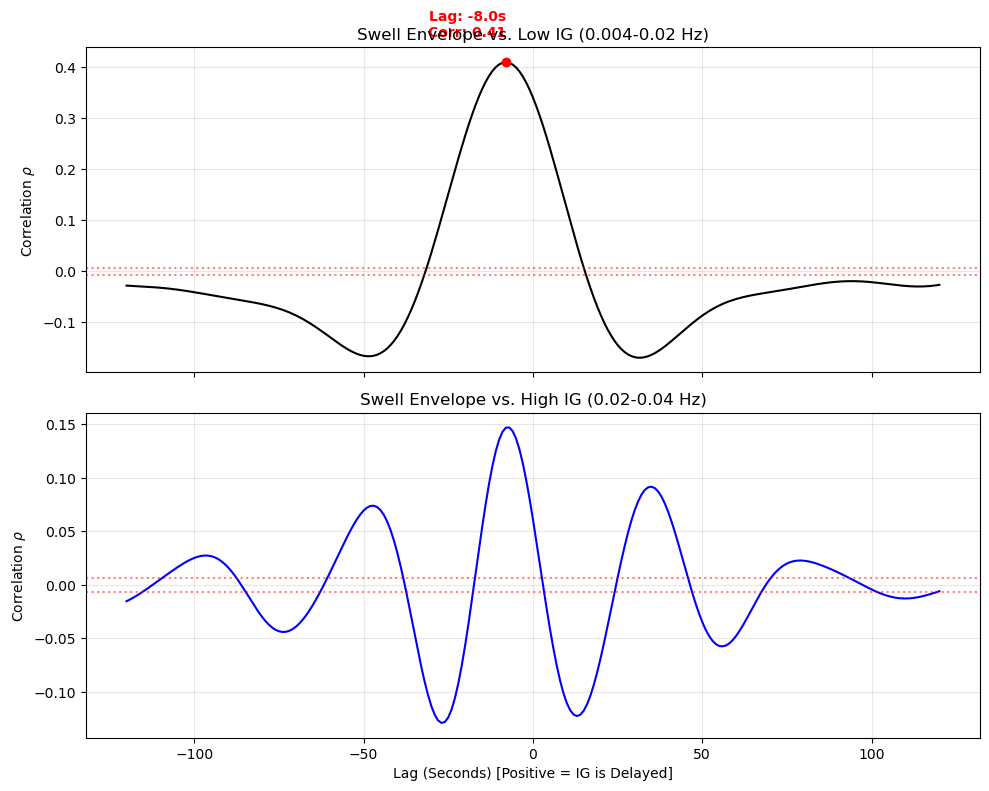

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate

def compute_te_ccf_rigorous(signal_ref, signal_lagged, fs=1.0, max_lag_sec=120):
    """
    Computes Cross-Correlation.
    INPUTS:
    signal_ref    : The 'Cause' (e.g., Swell Envelope)
    signal_lagged : The 'Effect' (e.g., IG Waves)
    
    INTERPRETATION:
    Positive Lag (+) means 'signal_lagged' occurs AFTER 'signal_ref'.
    (i.e., The Effect is delayed relative to the Cause).
    """
    # 1. Demean
    x = signal_ref - np.mean(signal_ref)
    y = signal_lagged - np.mean(signal_lagged)
    N = len(x)
    
    # 2. Variance for Normalization (Biased Estimator 1/N)
    #
    var_x = np.sum(x**2) / N
    var_y = np.sum(y**2) / N
    denom = np.sqrt(var_x * var_y)
    
    # 3. Cross-Covariance
    # We use mode='full'. The output index 'N' corresponds to lag 0.
    # Correlations at indices > N are Positive Lags (y is shifted forward)
    cov = correlate(x, y, mode='full', method='fft') / N
    rho = cov / denom
    
    # 4. Lags Vector
    # correlate returns lags from -(N-1) to +(N-1)
    lags_idx = np.arange(-(N-1), N)
    lags_sec = lags_idx / fs
    
    # 5. Subset
    mask = (np.abs(lags_sec) <= max_lag_sec)
    
    # 6. Significance
    sig_level = 1.96 / np.sqrt(N)
    
    return lags_sec[mask], rho[mask], sig_level

# --- Execution ---
# (Assumes 'envelope', 'ig_lo', 'ig_hi' are already filtered from previous steps)

# Note the order: (Envelope, IG) -> Positive Lag means IG is DELAYED.
lags_lo, rho_lo, sig_lo = compute_te_ccf_rigorous(envelope, ig_lo)
lags_hi, rho_hi, sig_hi = compute_te_ccf_rigorous(envelope, ig_hi)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Low IG
ax1.plot(lags_lo, rho_lo, 'k-', lw=1.5)
ax1.axhline(sig_lo, color='r', ls=':', alpha=0.5, label='95% Significance')
ax1.axhline(-sig_lo, color='r', ls=':', alpha=0.5)
ax1.set_title(r'Swell Envelope vs. Low IG (0.004-0.02 Hz)')
ax1.set_ylabel(r'Correlation $\rho$')
ax1.grid(True, alpha=0.3)

# Annotate Peak
pk_idx = np.argmax(np.abs(rho_lo))
pk_lag = lags_lo[pk_idx]
pk_val = rho_lo[pk_idx]
ax1.plot(pk_lag, pk_val, 'ro')
ax1.text(pk_lag, pk_val + 0.05, f'Lag: {pk_lag:.1f}s\nCorr: {pk_val:.2f}', 
         ha='right', color='red', fontweight='bold')

# High IG
ax2.plot(lags_hi, rho_hi, 'b-', lw=1.5)
ax2.axhline(sig_hi, color='r', ls=':', alpha=0.5)
ax2.axhline(-sig_hi, color='r', ls=':', alpha=0.5)
ax2.set_title(r'Swell Envelope vs. High IG (0.02-0.04 Hz)')
ax2.set_ylabel(r'Correlation $\rho$')
ax2.set_xlabel('Lag (Seconds) [Positive = IG is Delayed]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

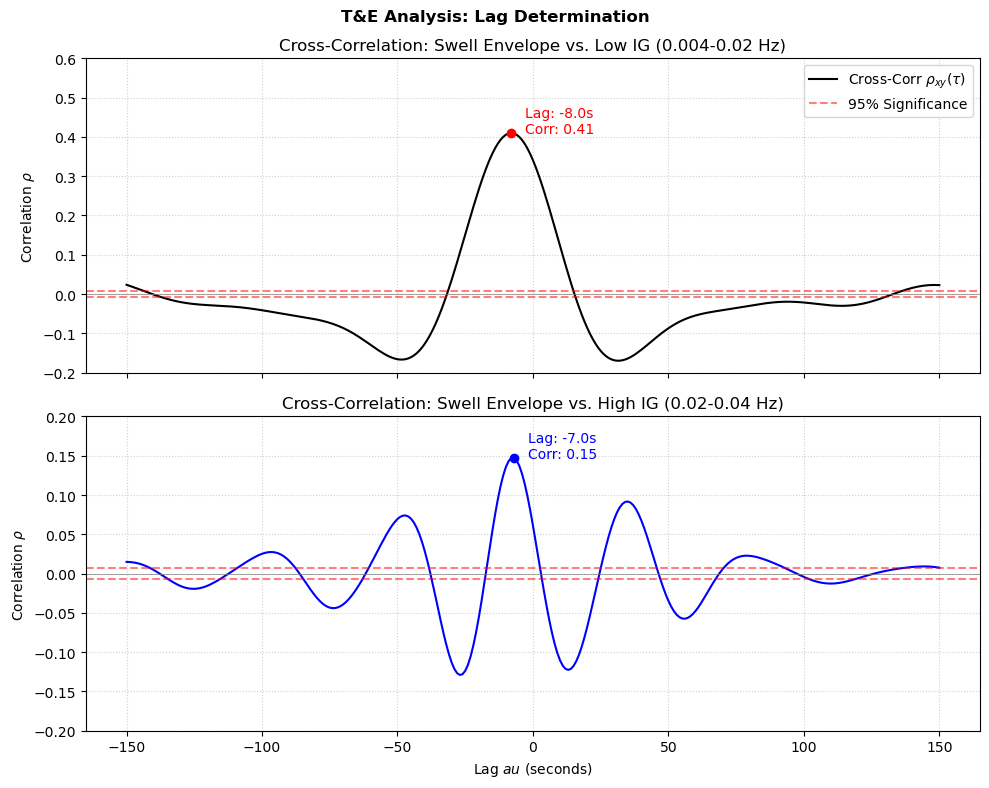

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate

def compute_thomson_emery_ccf(x, y, fs=1.0, max_lag_sec=120):
    """
    Computes the Cross-Correlation Function (CCF) following Thomson & Emery.
    
    Methodology:
    1. Demeans both series (centering).
    2. Computes Cross-Covariance R_xy(tau) using the 'biased' (1/N) normalization 
       favored by T&E for positive definite properties.
    3. Normalizes by variance to get rho_xy(tau).
    4. Calculates Significance Levels (95% CI).
    
    Parameters:
    -----------
    x : array-like
        Input signal 1 (e.g., Swell Envelope).
    y : array-like
        Input signal 2 (e.g., IG Waves).
    fs : float
        Sampling frequency (Hz).
    max_lag_sec : float
        Maximum lag to compute in seconds.
        
    Returns:
    --------
    lags_sec : array
        Lag vector in seconds.
    rho : array
        Cross-correlation coefficients.
    conf_level : float
        The 95% significance threshold (approximate).
    """
    N = len(x)
    
    # 1. Demean the signals (Required for Covariance)
    x_prime = x - np.mean(x)
    y_prime = y - np.mean(y)
    
    # 2. Compute Variances (R_xx(0) and R_yy(0))
    # We use N as the divisor to be consistent with the cross-term below
    var_x = np.sum(x_prime**2) / N
    var_y = np.sum(y_prime**2) / N
    denom = np.sqrt(var_x * var_y)
    
    # 3. Compute Cross-Covariance
    # scipy.signal.correlate computes the unnormalized sum: sum(x[t] * y[t+tau])
    # method='fft' is numerically standard for large N
    cov_raw = correlate(x_prime, y_prime, mode='full', method='fft')
    
    # Lags indices (-N+1 to N-1)
    lags_idx = np.arange(-N + 1, N)
    
    # Thomson & Emery normalize by N (biased estimator), NOT (N - |tau|)
    # This minimizes Mean Square Error of the spectral estimate.
    R_xy = cov_raw / N
    
    # 4. Normalize to Cross-Correlation rho_xy
    rho = R_xy / denom
    
    # 5. Subset to requested lag window
    max_lag_idx = int(max_lag_sec * fs)
    mask = (lags_idx >= -max_lag_idx) & (lags_idx <= max_lag_idx)
    
    lags_out = lags_idx[mask] / fs
    rho_out = rho[mask]
    
    # 6. Significance Level (95% CI for Zero Correlation)
    # Approx 1.96 / sqrt(N). 
    # Note: For highly autocorrelated data (like IG waves), N should theoretically 
    # be replaced by N_effective (integral time scale), making this a *minimum* bound.
    significance = 1.96 / np.sqrt(N)
    
    return lags_out, rho_out, significance

# ==========================================
# MAIN EXECUTION
# ==========================================


# Input 1: Swell Envelope A(t) (Forced Method)
# (Assumes df1_forced is already available from previous steps)
# Reindex to ensure strict alignment
common_idx = df1.loc[txi:txf].index
envelope = df1_forced['A'].reindex(common_idx).fillna(0).values

# Input 2: Raw Sea Surface h(t)
h_raw = df1['h'].loc[txi:txf].values

# Filter IG Bands (Butterworth 4th order)
fs = 1.0 # Hz
nyq = 0.5 * fs

# Low IG (0.004 - 0.02 Hz) - "Surf Beat"
b_lo, a_lo = butter(4, [0.004/nyq, 0.02/nyq], btype='band')
ig_lo = filtfilt(b_lo, a_lo, h_raw)

# High IG (0.02 - 0.04 Hz) - "Break Point"
b_hi, a_hi = butter(4, [0.02/nyq, 0.04/nyq], btype='band')
ig_hi = filtfilt(b_hi, a_hi, h_raw)

# 2. Run Cross-Correlation Analysis
# ---------------------------------
# We look for lags up to +/- 120 seconds
lags_lo, rho_lo, sig_lo = compute_thomson_emery_ccf(envelope, ig_lo, fs=fs, max_lag_sec=150)
lags_hi, rho_hi, sig_hi = compute_thomson_emery_ccf(envelope, ig_hi, fs=fs, max_lag_sec=150)

# 3. Plotting
# -----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Low Frequency IG
ax1.plot(lags_lo, rho_lo, 'k-', linewidth=1.5, label=r'Cross-Corr $\rho_{xy}(\tau)$')
ax1.axhline(sig_lo, color='r', linestyle='--', alpha=0.5, label='95% Significance')
ax1.axhline(-sig_lo, color='r', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_ylabel(r'Correlation $\rho$')
ax1.set_ylim(-0.2, 0.6)
ax1.set_title(r'Cross-Correlation: Swell Envelope vs. Low IG (0.004-0.02 Hz)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Find Peak
idx_max_lo = np.argmax(np.abs(rho_lo))
ax1.plot(lags_lo[idx_max_lo], rho_lo[idx_max_lo], 'ro')
ax1.text(lags_lo[idx_max_lo]+5, rho_lo[idx_max_lo], 
         f'Lag: {lags_lo[idx_max_lo]:.1f}s\nCorr: {rho_lo[idx_max_lo]:.2f}', 
         color='red')


# Plot 2: High Frequency IG
ax2.plot(lags_hi, rho_hi, 'b-', linewidth=1.5, label=r'Cross-Corr $\rho_{xy}(\tau)$')
ax2.axhline(sig_hi, color='r', linestyle='--', alpha=0.5)
ax2.axhline(-sig_hi, color='r', linestyle='--', alpha=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel(r'Correlation $\rho$')
ax2.set_ylim(-0.2, 0.2)
ax2.set_xlabel('Lag $\tau$ (seconds)')
ax2.set_title(r'Cross-Correlation: Swell Envelope vs. High IG (0.02-0.04 Hz)')
ax2.grid(True, linestyle=':', alpha=0.6)

# Find Peak
idx_max_hi = np.argmax(np.abs(rho_hi))
ax2.plot(lags_hi[idx_max_hi], rho_hi[idx_max_hi], 'bo')
ax2.text(lags_hi[idx_max_hi]+5, rho_hi[idx_max_hi], 
         f'Lag: {lags_hi[idx_max_hi]:.1f}s\nCorr: {rho_hi[idx_max_hi]:.2f}', 
         color='blue')

# Interpretation Note
fig.suptitle('T&E Analysis: Lag Determination', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:

# 1. Setup Data
# -------------
# Re-filter to ensure we have clean variables matching the PDF context
# Using the full 12-hour window you defined previously
ti_analysis = pd.Timestamp("2008-01-13 18:00:00")
tf_analysis = pd.Timestamp("2008-01-14 06:00:00")

# Input 1: Swell Envelope A(t) (Forced Method)
# (Assumes df1_forced is already available from previous steps)
# Reindex to ensure strict alignment
common_idx = df1.loc[ti_analysis:tf_analysis].index
envelope = df6_standard['A'].reindex(common_idx).fillna(0).values

# Input 2: Raw Sea Surface h(t)
h_raw = df1['h'].loc[ti_analysis:tf_analysis].values

# Filter IG Bands (Butterworth 4th order)
fs = 1.0 # Hz
nyq = 0.5 * fs

# Low IG (0.004 - 0.02 Hz) - "Surf Beat"
b_lo, a_lo = butter(4, [0.004/nyq, 0.02/nyq], btype='band')
ig_lo = filtfilt(b_lo, a_lo, h_raw)

# High IG (0.02 - 0.04 Hz) - "Break Point"
b_hi, a_hi = butter(4, [0.02/nyq, 0.04/nyq], btype='band')
ig_hi = filtfilt(b_hi, a_hi, h_raw)

# 2. Run Cross-Correlation Analysis
# ---------------------------------
# We look for lags up to +/- 120 seconds
lags_lo, rho_lo, sig_lo = compute_thomson_emery_ccf(envelope, ig_lo, fs=fs, max_lag_sec=150)
lags_hi, rho_hi, sig_hi = compute_thomson_emery_ccf(envelope, ig_hi, fs=fs, max_lag_sec=150)

# 3. Plotting
# -----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Low Frequency IG
ax1.plot(lags_lo, rho_lo, 'k-', linewidth=1.5, label=r'Cross-Corr $\rho_{xy}(\tau)$')
ax1.axhline(sig_lo, color='r', linestyle='--', alpha=0.5, label='95% Significance')
ax1.axhline(-sig_lo, color='r', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_ylabel(r'Correlation $\rho$')
ax1.set_title(r'Cross-Correlation: Swell Envelope vs. Low IG (0.004-0.02 Hz)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Find Peak
idx_max_lo = np.argmax(np.abs(rho_lo))
ax1.plot(lags_lo[idx_max_lo], rho_lo[idx_max_lo], 'ro')
ax1.text(lags_lo[idx_max_lo]+5, rho_lo[idx_max_lo], 
         f'Lag: {lags_lo[idx_max_lo]:.1f}s\nCorr: {rho_lo[idx_max_lo]:.2f}', 
         color='red')

# Plot 2: High Frequency IG
ax2.plot(lags_hi, rho_hi, 'b-', linewidth=1.5, label=r'Cross-Corr $\rho_{xy}(\tau)$')
ax2.axhline(sig_hi, color='r', linestyle='--', alpha=0.5)
ax2.axhline(-sig_hi, color='r', linestyle='--', alpha=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel(r'Correlation $\rho$')
ax2.set_xlabel('Lag $\tau$ (seconds)')
ax2.set_title(r'Cross-Correlation: Swell Envelope vs. High IG (0.02-0.04 Hz)')
ax2.grid(True, linestyle=':', alpha=0.6)

# Find Peak
idx_max_hi = np.argmax(np.abs(rho_hi))
ax2.plot(lags_hi[idx_max_hi], rho_hi[idx_max_hi], 'bo')
ax2.text(lags_hi[idx_max_hi]+5, rho_hi[idx_max_hi], 
         f'Lag: {lags_hi[idx_max_hi]:.1f}s\nCorr: {rho_hi[idx_max_hi]:.2f}', 
         color='blue')

# Interpretation Note
fig.suptitle('T&E Analysis: Lag Determination', fontsize=12)

plt.tight_layout()
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate

# 1. Get the "Clean Input" (Offshore Envelope)
# We use the standard CD method on the OFFSHORE sensor (df6)
# (Assuming df6 is loaded and has column 'h')
print("Calculating Offshore Envelope (Input)...")
# Using the same Swell Band (SS) as before
SS = (0.04, 0.20) 
res_offshore = complex_demod_hourly(
    df6, 
    txi, 
    txf, 
    p_col="h",  
    f0_method='peak' # Standard peak method is fine for deep water
)
envelope_off = res_offshore['A']

# 2. Get the "Response" (Nearshore IG)
# (Same filtering as before on df1)
print("Filtering Nearshore IG (Output)...")
# Low IG Band
b_lo, a_lo = butter(4, [0.004/0.5, 0.02/0.5], btype='band')
ig_lo_near = filtfilt(b_lo, a_lo, df1['h'].loc[txi:txf].values)

# High IG Band
b_hi, a_hi = butter(4, [0.02/0.5, 0.04/0.5], btype='band')
ig_hi_near = filtfilt(b_hi, a_hi, df1['h'].loc[txi:txf].values)

# 3. Compute Cross-Correlation (Input vs Output)
# We use the 'Rigorous' function from before
# Remember: Input First, Output Second -> Positive Lag means Output is Delayed
lags_lo, rho_lo, sig_lo = compute_thomson_emery_ccf(envelope_off, ig_lo_near, max_lag_sec=300) # Increased max lag to 300s to account for travel time

# 4. Plotting
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# Low IG
ax1.plot(lags_lo, rho_lo, 'k-', lw=1.5)
ax1.axhline(sig_lo, color='r', ls=':', alpha=0.5, label='95% Significance')
ax1.axhline(-sig_lo, color='r', ls=':', alpha=0.5)
fig.suptitle(r'Cross-Correlation: Offshore Envelope vs. Nearshore Low IG')
ax1.set_ylabel(r'Correlation $\rho$')
ax1.grid(True, alpha=0.3)

# Find Peak
pk_idx = np.argmax(np.abs(rho_lo))
pk_lag = lags_lo[pk_idx]
pk_val = rho_lo[pk_idx]
ax1.plot(pk_lag, pk_val, 'ro')
ax1.text(pk_lag, pk_val + 0.05, f'Travel Time: {pk_lag:.1f}s\nCorr: {pk_val:.2f}', 
         ha='left', color='red', fontweight='bold')


plt.tight_layout()
plt.show()

Calculating Offshore Envelope (Input)...
Filtering Nearshore IG (Output)...


IndexError: boolean index did not match indexed array along dimension 0; dimension is 172726 but corresponding boolean dimension is 172731

Calculating Offshore Envelope (Input)...
Aligning Data... (Offshore: 86366, Nearshore: 86361)
Aligned length: 86366
Filtering Aligned Nearshore IG...


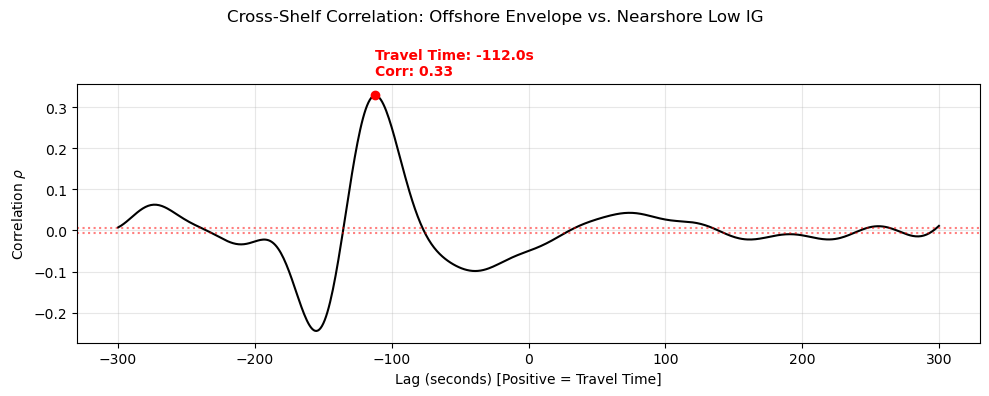

In [38]:
# 1. Get the "Clean Input" (Offshore Envelope)
print("Calculating Offshore Envelope (Input)...")
res_offshore = complex_demod_hourly(
    df6, 
    txi, 
    txf, 
    p_col="h",  
    f0_method='peak' 
)
# Keep as a Series with Index
s_env_off = res_offshore['A']

# 2. Get the "Response" Raw Data (Nearshore)
# Keep as a Series with Index initially
s_near_raw = df1['h'].loc[txi:txf]

# 3. ALIGN THE DATA (Crucial Step)
# This finds the intersection of times and ensures equal length
print(f"Aligning Data... (Offshore: {len(s_env_off)}, Nearshore: {len(s_near_raw)})")
s_env_aligned, s_near_aligned = s_env_off.align(s_near_raw, join='inner')
print(f"Aligned length: {len(s_env_aligned)}")

# 4. Filter the ALIGNED Nearshore Data
# Now we convert to numpy values for filtering
print("Filtering Aligned Nearshore IG...")

# Low IG Band
b_lo, a_lo = butter(4, [0.004/0.5, 0.02/0.5], btype='band')
ig_lo_near = filtfilt(b_lo, a_lo, s_near_aligned.values)

# High IG Band
b_hi, a_hi = butter(4, [0.02/0.5, 0.04/0.5], btype='band')
ig_hi_near = filtfilt(b_hi, a_hi, s_near_aligned.values)

# 5. Compute Cross-Correlation
# Now both inputs (s_env_aligned.values and ig_lo_near) are guaranteed to be the same size
lags_lo, rho_lo, sig_lo = compute_thomson_emery_ccf(
    s_env_aligned.values, 
    ig_lo_near, 
    max_lag_sec=300
)

# 6. Plotting
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

# Low IG
ax1.plot(lags_lo, rho_lo, 'k-', lw=1.5)
ax1.axhline(sig_lo, color='r', ls=':', alpha=0.5, label='95% Significance')
ax1.axhline(-sig_lo, color='r', ls=':', alpha=0.5)
fig.suptitle(r'Cross-Shelf Correlation: Offshore Envelope vs. Nearshore Low IG')
ax1.set_ylabel(r'Correlation $\rho$')
ax1.set_xlabel('Lag (seconds) [Positive = Travel Time]')
ax1.grid(True, alpha=0.3)

# Find Peak
pk_idx = np.argmax(np.abs(rho_lo))
pk_lag = lags_lo[pk_idx]
pk_val = rho_lo[pk_idx]
ax1.plot(pk_lag, pk_val, 'ro')
ax1.text(pk_lag, pk_val + 0.05, f'Travel Time: {pk_lag:.1f}s\nCorr: {pk_val:.2f}', 
         ha='left', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

now I want to plot a time series to compare the swell envelope and the IG energy, but using a lag that corresponds with the computed best correlation from the cross-correlation function. This will help me visualize how well the swell envelope and IG energy are correlated when accounting for any time delay between them.

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# 1. USER CONFIGURATION
# ==========================================
# Plug in the lags you found from the cross-correlation peaks here:
# (Positive = IG is delayed relative to Env)
# (Negative = IG leads Env)
LAG_OFFSHORE_SEC = -105  # Example: Group travel time from Offshore -> Nearshore
LAG_NEARSHORE_SEC = -8 # Example: Negative lag you found locally

# Zoom Window (to see the waves clearly)
zoom_start = pd.Timestamp("2008-01-13 20:00:00")
zoom_end   = pd.Timestamp("2008-01-13 20:30:00")

target_idx = df1.loc[txi:txf].index

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# A. Get Nearshore IG (The "Reference" Signal)
# We use the filtered IG_Lo from your previous steps
# (Assuming df_scatter or similar exists, or we re-filter here for safety)
b_lo, a_lo = butter(4, [0.004/0.5, 0.02/0.5], btype='band')
ig_lo_near = filtfilt(b_lo, a_lo, s_near_aligned.values)


ig_reference = pd.Series(ig_lo_near, index=target_idx)

# B. Get Offshore SS Envelope
# (Recalculating briefly to ensure it's available)
res_off = complex_demod_hourly(df6, txi, txf, p_col="h", f_swell=(0.04, 0.20), f0_method='peak')
env_offshore = res_off['A']

# C. Get Nearshore SS Envelope
# (Using the forced one you calculated)
env_nearshore = df1_forced['A'].reindex(ig_reference.index).fillna(0)

# ==========================================
# 3. APPLY SHIFTS
# ==========================================
# We shift the ENVELOPE to match the IG.
# If Lag is +120s (IG is late), we shift Envelope forward (+120s) to align.
env_offshore_shifted = env_offshore.shift(periods=int(LAG_OFFSHORE_SEC * fs))
env_nearshore_shifted = env_nearshore.shift(periods=int(LAG_NEARSHORE_SEC * fs))

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# ---- PLOT 1: Offshore Envelope vs. Nearshore IG ----
# This visualizes the "Travel Time" and "Dispersion"
ax1.plot(ig_reference.index, ig_reference, 'k-', linewidth=1.5, label='Nearshore IG Wave', alpha=0.8)

# We use a twinx axis because Offshore waves are likely much bigger than Nearshore IG
ax1b = ax1.twinx()
ax1b.plot(env_offshore_shifted.index, env_offshore_shifted, 'r-', linewidth=1.5, alpha=0.6, 
          label=f'Offshore SS Envelope (Shifted {LAG_OFFSHORE_SEC}s)')

# Formatting
ax1.set_title(f'Offshore Envelope shifted by {LAG_OFFSHORE_SEC}s)')
ax1.set_ylabel('IG Elevation (m)')
ax1b.set_ylabel('Offshore Swell Amplitude (m)', color='r')
ax1.grid(True, linestyle=':', alpha=0.6)

# Legend (Manually combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


# Apply Zoom
ax1.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()

ValueError: Length of values (86366) does not match length of index (86361)

applying cross correlation but iteratively thru every 30min window to see how the lag changes over time. This will help us understand if the relationship between the offshore envelope and nearshore IG is consistent or if it varies with changing conditions.

In [ ]:
## --- rolling cross correlation analysis functino -- ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, butter, filtfilt

def rolling_cross_corr_analysis(
    envelope, 
    ig_waves, 
    window_min=30, 
    step_min=5, 
    fs=1.0, 
    max_lag_sec=120
):
    """
    Slides a window across the data to find how Correlation and Lag evolve.
    """
    # Define Timesteps
    window_size = pd.Timedelta(minutes=window_min)
    step_size = pd.Timedelta(minutes=step_min)
    
    start_time = envelope.index[0]
    end_time = envelope.index[-1] - window_size
    
    results = []
    times = []
    
    current_time = start_time
    
    print(f"Running Rolling Analysis ({window_min}m windows)...")
    
    while current_time <= end_time:
        # 1. Slice Window
        t_end = current_time + window_size
        env_win = envelope.loc[current_time:t_end]
        ig_win = ig_waves.loc[current_time:t_end]
        
        # Check data integrity
        if len(env_win) < 100 or len(ig_win) < 100:
            current_time += step_size
            continue
            
        # 2. Compute Thomson & Emery Cross-Correlation
        # Demean
        x = env_win.values - np.mean(env_win.values)
        y = ig_win.values - np.mean(ig_win.values)
        N = len(x)
        
        # Normalization factors (Variance)
        var_x = np.sum(x**2) / N
        var_y = np.sum(y**2) / N
        denom = np.sqrt(var_x * var_y)
        
        # Cross-Covariance (Biased Estimator)
        cov = correlate(x, y, mode='full', method='fft') / N
        rho = cov / denom
        
        # Lags
        lags = np.arange(-(N-1), N) / fs
        
        # 3. Find Peak within physical limits
        mask = (lags >= -max_lag_sec) & (lags <= max_lag_sec)
        lags_lim = lags[mask]
        rho_lim = rho[mask]
        
        # Find absolute max correlation (could be negative for bound waves!)
        idx_max = np.argmax(np.abs(rho_lim))
        
        peak_corr = rho_lim[idx_max]
        peak_lag = lags_lim[idx_max]
        
        results.append((peak_corr, peak_lag))
        times.append(current_time + window_size/2) # Plot at center of window
        
        current_time += step_size
        
    return pd.DataFrame(results, index=times, columns=['Correlation', 'Lag_sec'])


In [45]:

# ==========================================
# EXECUTION
# ==========================================

# 1. Prep Data (Using Nearshore IG vs Offshore Envelope as the robust test)
# (Assumes env_offshore and ig_lo_near are already calculated from previous steps)
# Ensure they are Series with datetime index
s_env = pd.Series(env_offshore, index=df1.loc[txi:txf].index) # Offshore Env
s_ig = pd.Series(ig_reference, index=df1.loc[txi:txf].index) # Nearshore IG

# 2. Run Rolling Analysis
df_roll = rolling_cross_corr_analysis(s_env, s_ig, window_min=30, step_min=5)

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Correlation Strength
# We plot Absolute Correlation to see "Strength" regardless of phase
ax1.plot(df_roll.index, np.abs(df_roll['Correlation']), 'k-', marker='.', linewidth=1.5)
ax1.set_ylabel('Correlation Strength $|R|$')
ax1.set_title('Where is the coupling strongest?')
ax1.grid(True, linestyle=':', alpha=0.6)

# Highlight the "Golden Hour" (Best Correlation)
best_time = df_roll['Correlation'].abs().idxmax()
best_val = df_roll['Correlation'].abs().max()
ax1.axvline(best_time, color='r', linestyle='--', alpha=0.5, label='Best Window')
ax1.text(best_time, best_val, f'  Max: {best_val:.2f}', color='r', fontweight='bold')

# Plot 2: Lag Evolution
ax2.plot(df_roll.index, df_roll['Lag_sec'], 'b-', marker='.', linewidth=1.5)
ax2.set_ylabel('Lag (seconds)')
ax2.set_title('How does the travel time / phase change?')
ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
ax2.grid(True, linestyle=':', alpha=0.6)

# Add "Best Lag" annotation
best_lag = df_roll.loc[best_time, 'Lag_sec']
ax2.axvline(best_time, color='r', linestyle='--', alpha=0.5)
ax2.text(best_time, best_lag, f'  Lag: {best_lag:.1f}s', color='r', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Best Correlation Period found at: {best_time}")
print(f"Correlation: {best_val:.3f}")
print(f"Lag: {best_lag:.1f} seconds")

ValueError: cannot reindex on an axis with duplicate labels

Re-filtering Nearshore IG to ensure alignment...
Starting Rolling Analysis...
Running Rolling Analysis (30m windows)...
DONE. Best Correlation: 0.549 at 2008-01-13 19:35:00
Lag at that time: -106.0 seconds


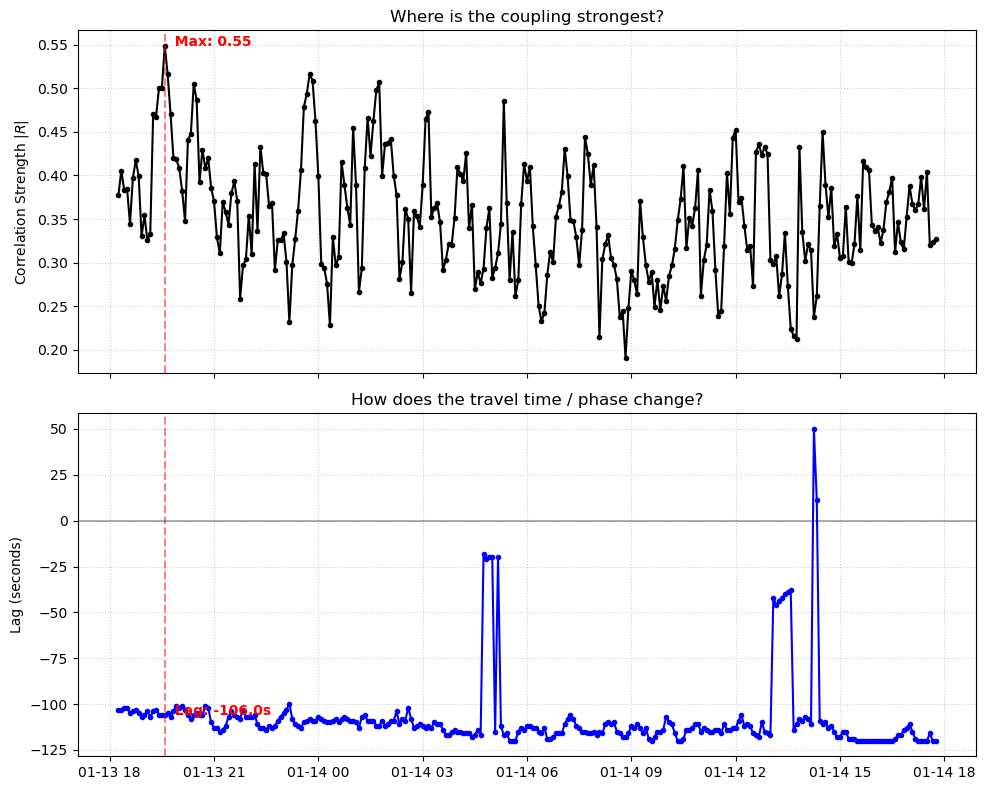

In [62]:
# ==========================================
# 1. FIX DUPLICATES & ALIGN DATA
# ==========================================

# A. Clean 'env_offshore'
# Remove any duplicate timestamps that occurred during hourly concatenation
if isinstance(env_offshore, pd.Series) or isinstance(env_offshore, pd.DataFrame):
    env_offshore = env_offshore[~env_offshore.index.duplicated(keep='first')]

# B. Prepare Target Index
# Get the clean timeline from the Nearshore sensor (df1)
target_idx = df1.loc[txi:txf].index

# C. Create the Aligned Series
# We use reindex() to force the Offshore Envelope onto the Nearshore timeline.
# tolerance='1s' allows for tiny mismatches in sampling times.
s_env = env_offshore.reindex(target_idx, method='nearest', tolerance=pd.Timedelta('1s'))

# D. Create Nearshore IG Series
# (Using the IG reference you calculated earlier, ensuring it matches the same index)
# Assuming 'ig_reference' or 'ig_lo_near' is available. 
# If not, we re-filter here to be safe:
print("Re-filtering Nearshore IG to ensure alignment...")
b_lo, a_lo = butter(4, [0.004/0.5, 0.02/0.5], btype='band')
ig_values = filtfilt(b_lo, a_lo, df1['h'].loc[txi:txf].values)
s_ig = pd.Series(ig_values, index=target_idx)

# ==========================================
# 2. RUN ROLLING ANALYSIS
# ==========================================
# Now that s_env and s_ig have identical, unique indices, this will run smooth.
print("Starting Rolling Analysis...")
df_roll = rolling_cross_corr_analysis(
    s_env.dropna(),     # Drop NaNs to avoid errors in correlation
    s_ig.dropna(), 
    window_min=30,      # 30-minute sliding window
    step_min=5          # Step forward 5 minutes
)

# ==========================================
# 3. PLOT RESULTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Correlation Strength
ax1.plot(df_roll.index, np.abs(df_roll['Correlation']), 'k-', marker='.', linewidth=1.5)
ax1.set_ylabel('Correlation Strength $|R|$')
ax1.set_title('Where is the coupling strongest?')
ax1.grid(True, linestyle=':', alpha=0.6)

# Highlight Best Window
if not df_roll.empty:
    best_time = df_roll['Correlation'].abs().idxmax()
    best_val = df_roll['Correlation'].abs().max()
    ax1.axvline(best_time, color='r', linestyle='--', alpha=0.5)
    ax1.text(best_time, best_val, f'  Max: {best_val:.2f}', color='r', fontweight='bold')

    # Plot 2: Lag Evolution
    ax2.plot(df_roll.index, df_roll['Lag_sec'], 'b-', marker='.', linewidth=1.5)
    ax2.set_ylabel('Lag (seconds)')
    ax2.set_title('How does the travel time / phase change?')
    ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Annotate Best Lag
    best_lag = df_roll.loc[best_time, 'Lag_sec']
    ax2.axvline(best_time, color='r', linestyle='--', alpha=0.5)
    ax2.text(best_time, best_lag, f'  Lag: {best_lag:.1f}s', color='r', fontweight='bold', va='baseline')
    
    print(f"DONE. Best Correlation: {best_val:.3f} at {best_time}")
    print(f"Lag at that time: {best_lag:.1f} seconds")
else:
    print("Warning: No results found. Check your input data alignment.")

plt.tight_layout()
plt.show()

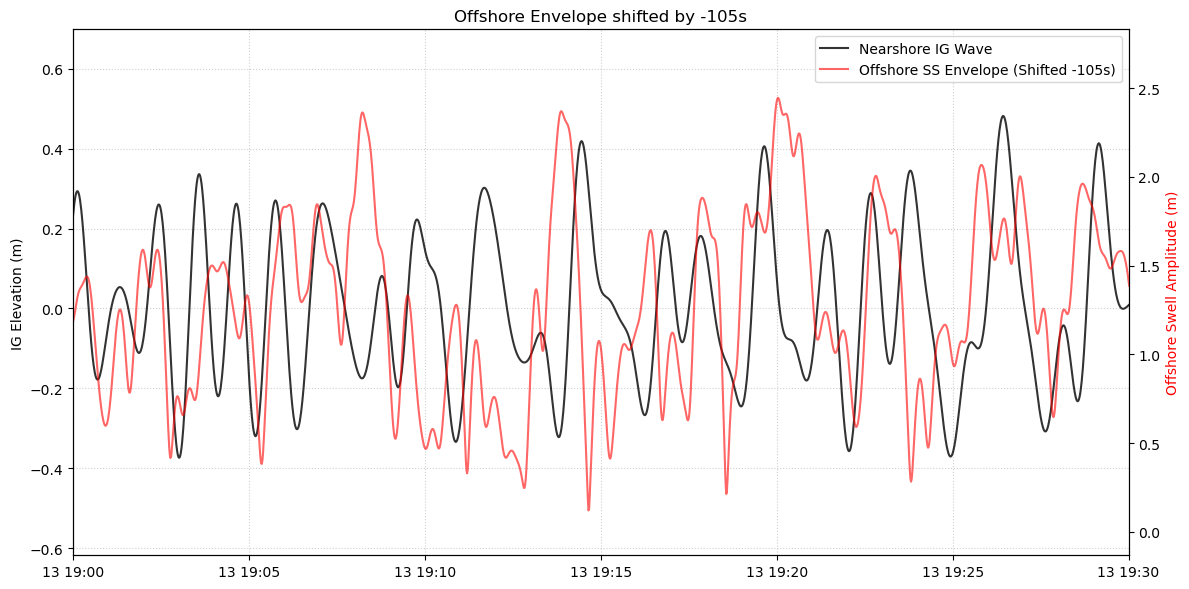

In [ ]:

LAG_OFFSHORE_SEC = -105  # Example: Group travel time from Offshore -> Nearshore

zoom_start = pd.Timestamp("2008-01-13 19:00:00")
zoom_end   = pd.Timestamp("2008-01-13 19:30:00")




# ==========================================
# 3. APPLY SHIFTS
# ==========================================
# We shift the ENVELOPE to match the IG.
# If Lag is +120s (IG is late), we shift Envelope forward (+120s) to align.
env_offshore_shifted = env_offshore.shift(periods=int(LAG_OFFSHORE_SEC * fs))

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# ---- PLOT 1: Offshore Envelope vs. Nearshore IG ----
# This visualizes the "Travel Time" and "Dispersion"
ax1.plot(ig_reference.index, ig_reference, 'k-', linewidth=1.5, label='Nearshore IG Wave', alpha=0.8)

# We use a twinx axis because Offshore waves are likely much bigger than Nearshore IG
ax1b = ax1.twinx()
ax1b.plot(env_offshore_shifted.index, env_offshore_shifted, 'r-', linewidth=1.5, alpha=0.6, 
          label=f'Offshore SS Envelope (Shifted {LAG_OFFSHORE_SEC}s)')

# Formatting
ax1.set_title(f'Offshore Envelope shifted by {LAG_OFFSHORE_SEC}s')
ax1.set_ylabel('IG Elevation (m)')
ax1b.set_ylabel('Offshore Swell Amplitude (m)', color='r')
ax1.grid(True, linestyle=':', alpha=0.6)

# Legend (Manually combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


# Apply Zoom
ax1.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()